Import Model Configuration
==========================

In [1]:
import yaml

model_cfg = "maskrcnn_resnet50_fpn_supervised.yaml"

with open("./configs/" + model_cfg , "r") as f:
    cfg = yaml.safe_load(f)

cfg['experiment_name']

'maskrcnn_resnet50_fpn_supervised'

Dataset Class
=============

In [2]:
import os
import torch
from torch.utils.data import Dataset
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
import numpy as np


class COCOSegmentationDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms

        # path to the JSON annotation file
        self.ann_path = os.path.join(root_dir, "_annotations.coco.json")
        self.coco = COCO(self.ann_path)
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root_dir, img_info['file_name'])

        img = read_image(img_path)  # shape: [C, H, W]
        img = tv_tensors.Image(img)
        h, w = img.shape[-2:]

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        masks = []
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            if 'segmentation' not in ann or not ann['segmentation']:
                continue  # Skip if missing or empty

            try:
                rles = coco_mask.frPyObjects(ann['segmentation'], h, w)
                mask = coco_mask.decode(rles)
            except Exception as e:
                print(f"[!] Skipping bad annotation in image {img_path}: {e}")
                continue
            if mask.ndim == 3:
                mask = mask.any(axis=2)
            mask = torch.as_tensor(mask, dtype=torch.uint8)
            masks.append(mask)

            x, y, bw, bh = ann['bbox']
            boxes.append(torch.tensor([x, y, x + bw, y + bh], dtype=torch.float32))
            labels.append(ann.get('category_id', 1))
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))

        if masks:
            masks = torch.stack(masks)
            boxes = torch.stack(boxes)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)
        else:
            masks = torch.zeros((0, h, w), dtype=torch.uint8)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=(h, w)),
            "masks": tv_tensors.Mask(masks),
            "labels": labels,
            "image_id": img_id,
            "area": areas,
            "iscrowd": iscrowd
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

            # ⚠️ Filter out zero-area boxes *after transforms*
            boxes = target["boxes"]
            keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])

            # Apply keep mask to all fields
            target["boxes"] = tv_tensors.BoundingBoxes(boxes[keep], format="XYXY", canvas_size=img.shape[-2:])
            target["labels"] = target["labels"][keep]
            if "masks" in target:
                target["masks"] = target["masks"][keep]
            if "area" in target:
                target["area"] = target["area"][keep]
            if "iscrowd" in target:
                target["iscrowd"] = target["iscrowd"][keep]

        return img, target

    def __len__(self):
        return len(self.ids)


Augmentiations
=============

In [3]:
from torchvision.transforms import v2 as T
import torch

def get_transform(train: bool):
    if train:
        transforms = [
            T.RandomPhotometricDistort(),  # Color jitter
            T.Resize((512, 512)),          # Fixed resize for stability
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10, fill=0, expand=False),  # Limit rotation area
            # T.RandomZoomOut(fill=0, p=0.3),  # Optional — leave off for now
            # T.RandomCrop((512, 512), pad_if_needed=False, fill=0),  # Only if images are bigger
        ]
    else:
        transforms = [
            T.Resize((512, 512)),                                   # Consistent resize for val/test
        ]

    transforms += [
        T.ToDtype(torch.float32, scale=True),                       # Convert image to float32 in [0, 1]
        T.ToPureTensor(),                                           # Convert to torch.Tensor (Image, Mask, BBoxes)
    ]

    return T.Compose(transforms)

Log Hyperparams to TensorBoard
===============================

In [4]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import shutil, os

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

log_dir = f"runs/{cfg['experiment_name']}_{timestamp}"

if os.path.exists(log_dir):
    shutil.rmtree(log_dir)

# Save cfg as hyperparameters (flatten dictionary)
def flatten_dict(d, parent_key="", sep="/"):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

writer = SummaryWriter(log_dir=f"runs/{cfg['experiment_name']}_{timestamp}")

# Option 1: Save flattened cfg to TensorBoard as hparams
flattened_cfg = flatten_dict(cfg)

# Option 2: Also log as text (for easier reading)
cfg_text = yaml.dump(cfg, sort_keys=False)
writer.add_text("config", f"```yaml\n{cfg_text}\n```")


Initialization
=============

In [5]:
import utils  # Your helper functions (make sure it includes `collate_fn` from PyTorch references)
import torch
from torchvision.transforms import v2 as T
from engine import train_one_epoch, evaluate


from models import MODEL_REGISTRY



device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


dataset = COCOSegmentationDataset(
    root_dir="../../../datasets/SupervisedDataset/train",
    transforms=get_transform(train=True)
)

dataset_valid = COCOSegmentationDataset(
    root_dir="../../../datasets/SupervisedDataset/val",
    transforms=get_transform(train=False)
)

dataset_test = COCOSegmentationDataset(
    root_dir="../../../datasets/SupervisedDataset/test",
    transforms=get_transform(train=False)
)


print("Train size:", len(dataset))
print("Validation size:", len(dataset_valid))
print("Test size:", len(dataset_test))

# Dynamically assign number of workers
n_workers = 4 if torch.cuda.is_available() else 0

# Dataloaders
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=cfg["train"]["batch_size"],
    shuffle=True,
    num_workers = n_workers,
    collate_fn=utils.collate_fn
)

data_loader_valid = torch.utils.data.DataLoader(
    dataset_valid,
    batch_size=1,
    shuffle=False,
    num_workers=n_workers,
    collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    num_workers=n_workers,
    collate_fn=utils.collate_fn
)

# Load model
model = MODEL_REGISTRY[cfg["model"]](num_classes=cfg["num_classes"])

# Load pretrained weights from synthetic training
model.load_state_dict(torch.load(
    "outputs/maskrcnn_resnet50_fpn_20250609_1525/model_best.pth",
    map_location=torch.device("cuda" if torch.cuda.is_available() else "cpu")
))

# Move to device
model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

loading annotations into memory...
Done (t=0.25s)
creating index...
index created!
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Train size: 170
Validation size: 48
Test size: 26


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

Train
=====

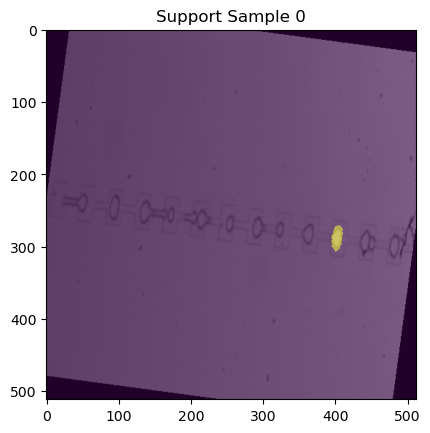

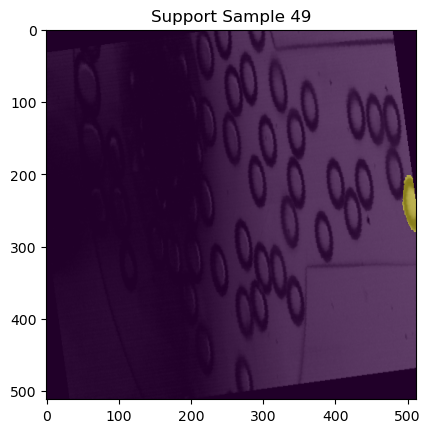

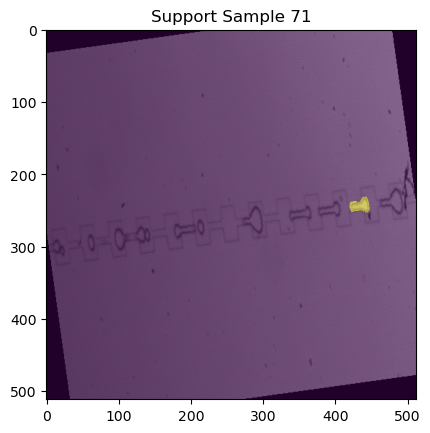

In [6]:
import matplotlib.pyplot as plt

for idx in [0,49,71]:
    img, tgt = dataset[idx]
    mask = tgt['masks'][0]
    plt.imshow(img.permute(1, 2, 0))
    plt.imshow(mask, alpha=0.5)
    plt.title(f"Support Sample {idx}")
    plt.show()

In [7]:
# === IFA-style Fine-Tuning on Few-Shot Real Images ===
# This replaces the full supervised fine-tuning loop.

import torch
import random
import torchvision.transforms.v2.functional as F
import torch.nn.functional as Fnn
from copy import deepcopy
from tqdm import tqdm

# --- Config ---
T = 3  # Number of BFP iterations
epochs = 20
learning_rate = 1e-4

# === Support-query pair builder ===
def build_support_query_pairs(dataset, k=1):
    support_idxs = [3, 14, 21]  # <-- example: manually chosen indices (1-shot, 3-shot, etc.)
    #support_idxs = random.sample(range(len(dataset)), k)
    support_set = [dataset[i] for i in support_idxs]

    pairs = []
    for img, tgt in support_set:
        aug_img, aug_tgt = apply_same_transform(img, tgt)
        pairs.append((img, tgt, aug_img, aug_tgt))
    return pairs

def apply_same_transform(image, target):
    angle = random.uniform(-10, 10)
    flipped = random.random() < 0.5

    image = F.resize(image, [512, 512])
    target["masks"] = F.resize(target["masks"].to(dtype=torch.float32), [512, 512]).to(dtype=torch.uint8)

    if flipped:
        image = F.hflip(image)
        target["masks"] = F.hflip(target["masks"])

    image = F.rotate(image, angle)
    target["masks"] = F.rotate(target["masks"], angle)

    return image, target

# === Support prototype via masked average pooling ===
def masked_avg_pool(features, mask):
    """
    features: [B, C, Hf, Wf]
    mask: [B, H, W] or [B, 1, H, W] — binary mask at image resolution
    """
    if mask.ndim == 3:  # [B, H, W]
        mask = mask.unsqueeze(1)
    elif mask.ndim == 4 and mask.shape[1] > 1:
        # If it's not a binary mask (e.g., 7 classes), reduce to 1
        mask = mask.sum(dim=1, keepdim=True)
        mask = (mask > 0).float()

    mask = mask.float()

    B, C, Hf, Wf = features.shape
    mask = F.resize(mask, size=[Hf, Wf], interpolation=F.InterpolationMode.NEAREST)

    # Now: features [B, C, Hf, Wf], mask [B, 1, Hf, Wf]
    weighted = features * mask
    return weighted.sum(dim=(2, 3)) / (mask.sum(dim=(2, 3)) + 1e-6)



# === Similarity + Interpolation ===
def cosine_similarity_interp(fmap, proto):
    proto = Fnn.normalize(proto, dim=-1).unsqueeze(-1).unsqueeze(-1)
    fmap = Fnn.normalize(fmap, dim=1)
    return Fnn.cosine_similarity(fmap, proto, dim=1)

# === IFA fine-tuning loop ===
def fine_tune_ifa(model, dataset, optimizer, device):
    model.train()
    for epoch in range(epochs):
        support_query_pairs = build_support_query_pairs(dataset, k=1)
        losses_epoch = []

        for support_img, support_tgt, query_img, query_tgt in support_query_pairs:
            support_img = support_img.to(device)
            query_img = query_img.to(device)

            #support_mask = support_tgt["masks"].to(device).float()
            #query_mask = query_tgt["masks"].to(device).float()
            support_mask = support_tgt["masks"][0].unsqueeze(0).to(device).float()  # shape: [1, H, W]
            query_mask = query_tgt["masks"][0].unsqueeze(0).to(device).float()      # shape: [1, H, W]


            #with torch.no_grad():
            Fs = model.backbone(support_img.unsqueeze(0))["0"]  # Feature map
            Fq = model.backbone(query_img.unsqueeze(0))["0"]
            
            print("Fs:", Fs.shape)
            print("support_mask:", support_mask.shape)

            Ps = masked_avg_pool(Fs, support_mask.unsqueeze(0))

            # Iterative refinement
            loss_total = 0
            Pq = None
            for t in range(T):
                Pq = masked_avg_pool(Fq, query_mask.unsqueeze(0)) if t == 0 else masked_avg_pool(Fq, Ms_q)
                Ms_q = cosine_similarity_interp(Fq, Ps).unsqueeze(0)
                Ms_s = cosine_similarity_interp(Fs, Pq).unsqueeze(0)

                # Downsample query/support masks to match feature map size (128x128)
                B, C, Hf, Wf = Ms_q.shape  # logits output shape
                query_mask_down = F.resize(query_mask.unsqueeze(0), [Hf, Wf], interpolation=F.InterpolationMode.NEAREST)
                support_mask_down = F.resize(support_mask.unsqueeze(0), [Hf, Wf], interpolation=F.InterpolationMode.NEAREST)

                loss_q = Fnn.binary_cross_entropy_with_logits(Ms_q, query_mask_down)
                loss_s = Fnn.binary_cross_entropy_with_logits(Ms_s, support_mask_down)

                loss_total += loss_q + loss_s

            optimizer.zero_grad()
            loss_total.backward()
            optimizer.step()

            losses_epoch.append(loss_total.item())

        print(f"[Epoch {epoch+1}/{epochs}] Avg Loss: {sum(losses_epoch)/len(losses_epoch):.4f}")

# === Setup ===
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
fine_tune_ifa(model, dataset, optimizer, device)

# Save adapted model
torch.save(model.state_dict(), "ifa_finetuned_model.pth")


Fs: torch.Size([1, 256, 128, 128])
support_mask: torch.Size([1, 512, 512])
Fs: torch.Size([1, 256, 128, 128])
support_mask: torch.Size([1, 512, 512])
Fs: torch.Size([1, 256, 128, 128])
support_mask: torch.Size([1, 512, 512])
[Epoch 1/20] Avg Loss: 5.0383
Fs: torch.Size([1, 256, 128, 128])
support_mask: torch.Size([1, 512, 512])
Fs: torch.Size([1, 256, 128, 128])
support_mask: torch.Size([1, 512, 512])
Fs: torch.Size([1, 256, 128, 128])
support_mask: torch.Size([1, 512, 512])
[Epoch 2/20] Avg Loss: 4.2819
Fs: torch.Size([1, 256, 128, 128])
support_mask: torch.Size([1, 512, 512])
Fs: torch.Size([1, 256, 128, 128])
support_mask: torch.Size([1, 512, 512])
Fs: torch.Size([1, 256, 128, 128])
support_mask: torch.Size([1, 512, 512])
[Epoch 3/20] Avg Loss: 4.4720
Fs: torch.Size([1, 256, 128, 128])
support_mask: torch.Size([1, 512, 512])
Fs: torch.Size([1, 256, 128, 128])
support_mask: torch.Size([1, 512, 512])
Fs: torch.Size([1, 256, 128, 128])
support_mask: torch.Size([1, 512, 512])
[Epoch 4/2

Evaluate
=====

In [8]:
from engine import evaluate

coco_evaluator = evaluate(model, data_loader_test, device=device)
segm_eval = coco_evaluator.coco_eval["segm"]
segm_eval.stats  # Returns mAP and other metrics


creating index...
index created!
Test:  [ 0/26]  eta: 0:00:40  model_time: 1.0076 (1.0076)  evaluator_time: 0.1524 (0.1524)  time: 1.5589  data: 0.3944  max mem: 1087
Test:  [25/26]  eta: 0:00:00  model_time: 0.3130 (0.3500)  evaluator_time: 0.0831 (0.1017)  time: 0.4313  data: 0.0044  max mem: 1087
Test: Total time: 0:00:12 (0.4759 s / it)
Averaged stats: model_time: 0.3130 (0.3500)  evaluator_time: 0.0831 (0.1017)
Accumulating evaluation results...
DONE (t=0.02s).
Accumulating evaluation results...
DONE (t=0.02s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.024
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.075
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.006
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | max

array([0.04898825, 0.1008709 , 0.04102275, 0.        , 0.05501321,
       0.5775452 , 0.01432432, 0.09351351, 0.30189189, 0.        ,
       0.20915751, 0.58085106])

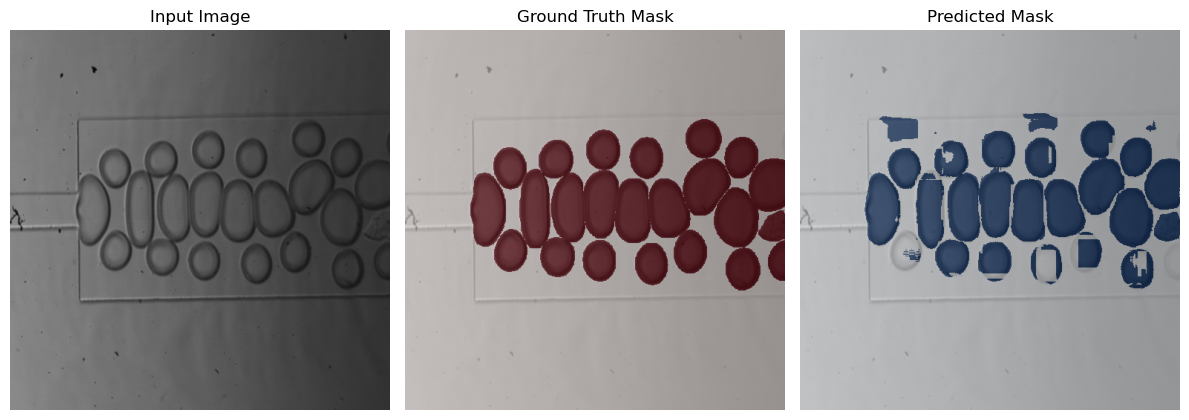

In [10]:
import matplotlib.pyplot as plt
import torch

def visualize_prediction_vs_gt(model, dataset, idx=0, device='cuda'):
    model.eval()

    # Get image and ground truth
    img, tgt = dataset[idx]
    img_gpu = img.to(device)
    with torch.no_grad():
        output = model([img_gpu])[0]

    # Extract prediction and ground truth masks
    pred_masks = output['masks']  # [N, 1, H, W]
    pred_mask_combined = torch.any(pred_masks.squeeze(1) > 0.5, dim=0).cpu() if len(pred_masks) > 0 else torch.zeros_like(img[0], dtype=torch.uint8)

    gt_masks = tgt['masks']  # [N, H, W]
    gt_mask_combined = torch.any(gt_masks > 0, dim=0).cpu()

    # Prepare the original image for plotting
    img_np = img.permute(1, 2, 0).cpu().numpy()

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    axes[1].imshow(img_np)
    axes[1].imshow(gt_mask_combined, alpha=0.5, cmap="Reds")
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis("off")

    axes[2].imshow(img_np)
    axes[2].imshow(pred_mask_combined, alpha=0.5, cmap="Blues")
    axes[2].set_title("Predicted Mask")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


visualize_prediction_vs_gt(model, dataset_test, idx=0, device=device)